In [1]:
import torch
import matplotlib.pyplot as plt

# Generate synthetic data for X ranging from -30 to 29 with a step size of 1
X = torch.arange(-30, 30, 1).view(-1, 1).type(torch.FloatTensor)

# Initialize an empty tensor Y to store the labels (target values)
Y = torch.zeros(X.shape[0])

# Assign label 1.0 to elements in Y where the corresponding X value is less than or equal to -10
Y[X[:, 0] <= -10] = 1.0

# Assign label 0.5 to elements in Y where the corresponding X value falls between -10 and 10 (exclusive)
Y[(X[:, 0] > -10) & (X[:, 0] < 10)] = 0.5

# Assign label 0 to elements in Y where the corresponding X value is greater than 10
Y[X[:, 0] > 10] = 0

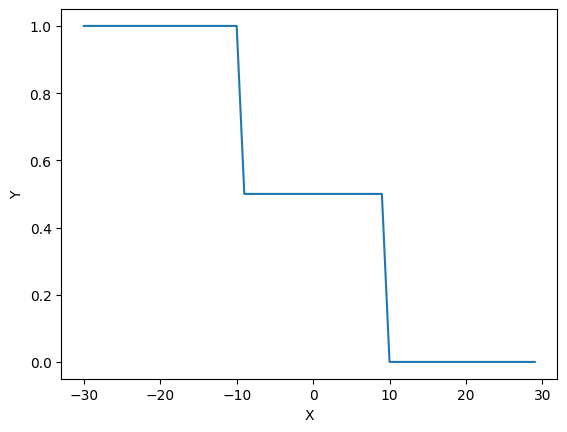

In [2]:
import matplotlib.pyplot as plt


# Create a plot of X against Y
plt.plot(X, Y)

# Add X and Y labels to the plot
plt.xlabel('X')
plt.ylabel('Y')

# Display the plot
plt.show()

In [7]:
import torch.nn as nn
class SingleLayerNet(nn.Module):
    def __init__(self, input_size, hidden_neurons, output_size):
        super(SingleLayerNet, self).__init__()
        # Define the hidden layer with input_size input features and hidden_neurons neurons
        self.hidden_layer = nn.Linear(input_size, hidden_neurons)

        # Define the output layer with hidden_neurons input features and output_size neurons
        self.output_layer = nn.Linear(hidden_neurons, output_size)
        
#Define a Prediction Function
    def forward(self, x):
        # Pass the input through the hidden layer and apply the sigmoid activation function
        hidden_output = torch.sigmoid(self.hidden_layer(x))

        # Pass the hidden layer output through the output layer and apply the sigmoid activation function
        y_pred = torch.sigmoid(self.output_layer(hidden_output))

        return y_pred
    

# create the model 
model = SingleLayerNet(1, 2, 1)  
# 2 represents two neurons in one hidden layer

In [8]:
import torch.optim as optim
# Define the loss function (criterion)
def criterion(y_pred, y_true):
    # Binary Cross Entropy Loss
    # y_pred: predicted probabilities, y_true: true labels (0 or 1)
    
    # Compute the negative log likelihood loss using binary cross-entropy formula
    # (y * log(y_pred) + (1 - y) * log(1 - y_pred))
    loss = -1 * (y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))
    
    # Calculate the mean loss over the batch
    mean_loss = torch.mean(loss)
    
    return mean_loss

# Assuming 'model' is an instance of your custom neural network
# Create an optimizer (Stochastic Gradient Descent - SGD)
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [9]:
# Define the loss function (criterion)
def criterion(y_pred, y_true):
    # Binary Cross Entropy Loss
    # y_pred: predicted probabilities, y_true: true labels (0 or 1)
    
    # Compute the negative log likelihood loss using binary cross-entropy formula
    # (y * log(y_pred) + (1 - y) * log(1 - y_pred))
    loss = -1 * (y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))
    
    # Calculate the mean loss over the batch
    mean_loss = torch.mean(loss)
    
    return mean_loss

# Assuming 'model' is an instance of your custom neural network
# Create an optimizer (Stochastic Gradient Descent - SGD)
optimizer = optim.SGD(model.parameters(), lr=0.01)

Epoch 1000 done!


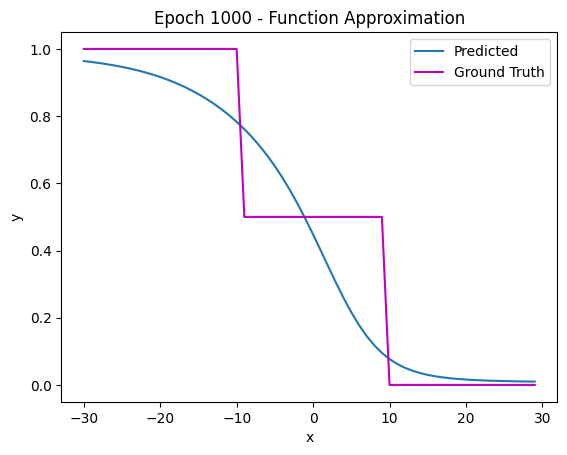

Epoch 2000 done!


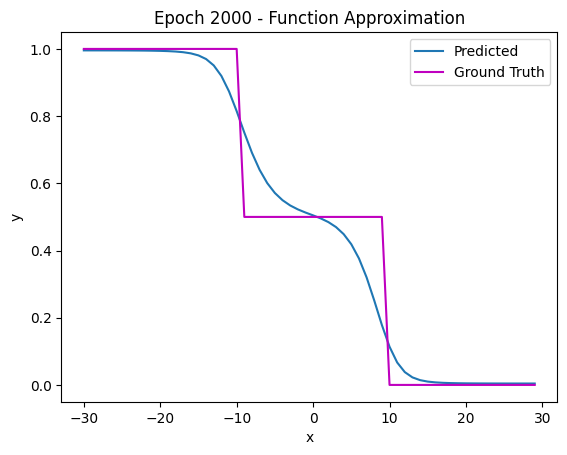

Epoch 3000 done!


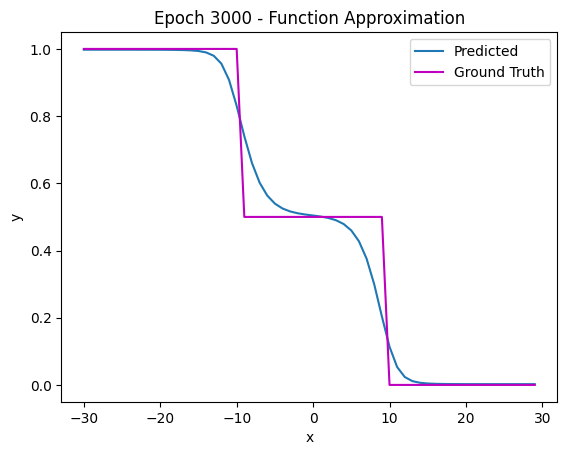

Epoch 4000 done!


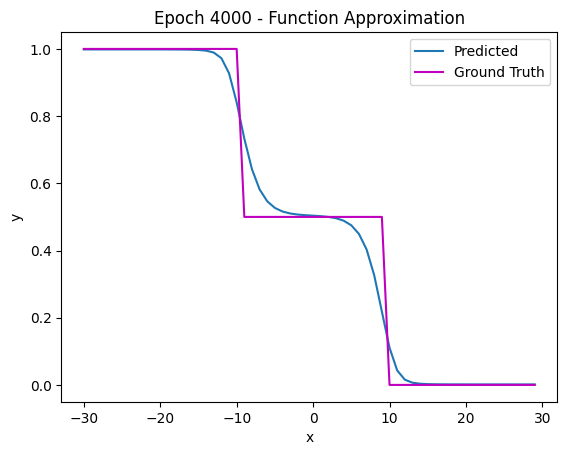

Epoch 5000 done!


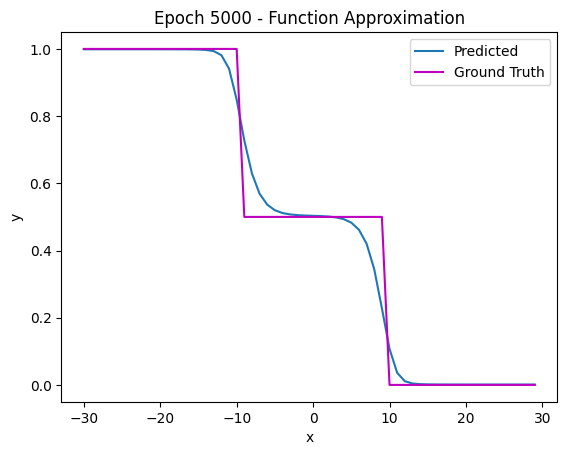

In [10]:
# Define the training loop
epochs = 5000
cost = []  # List to store the total loss at each epoch

for epoch in range(epochs):
    total_loss = 0  # Variable to store the total loss for the current epoch
    epoch = epoch + 1  # Increment the epoch count

    for x, y in zip(X, Y):
        # Forward pass: Calculate the predicted output (yhat) using the model
        yhat = model(x)

        # Calculate the loss between the predicted output (yhat) and the actual target (y)
        loss = criterion(yhat, y)

        # Backpropagation: Compute gradients of the model parameters with respect to the loss
        loss.backward()

        # Update the model parameters using the computed gradients
        optimizer.step()

        # Zero out the gradients for the next iteration to avoid accumulation
        optimizer.zero_grad()

        # Accumulate the loss for this batch of data
        total_loss += loss.item()

    # Append the total loss for this epoch to the cost list
    cost.append(total_loss)

    if epoch % 1000 == 0:
        print(f"Epoch {epoch} done!")  # Print status after every 1000 epochs

        # Plot the result of the function approximator
        predicted_values = model(X).detach().numpy()
        plt.plot(X.numpy(), predicted_values)  # Plot the predicted values
        plt.plot(X.numpy(), Y.numpy(), 'm')  # Plot the ground truth data (Y)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.legend(['Predicted', 'Ground Truth'])
        plt.title(f'Epoch {epoch} - Function Approximation')
        plt.show()

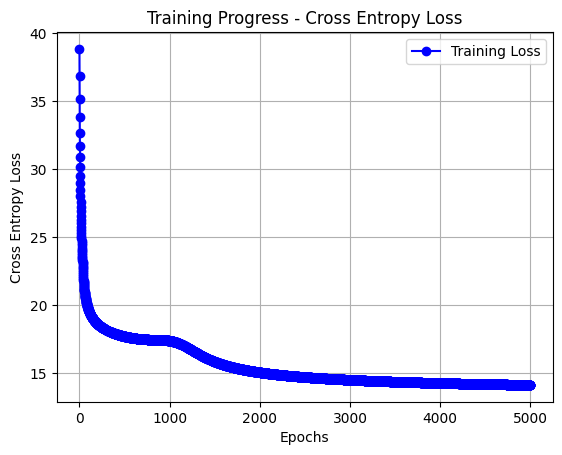

In [11]:
# Plot the cost (loss) over epochs
plt.plot(cost, marker='o', linestyle='-', color='b', label='Training Loss')

# Set labels and title
plt.xlabel('Epochs')
plt.ylabel('Cross Entropy Loss')
plt.title('Training Progress - Cross Entropy Loss')

# Add grid for better readability
plt.grid(True)

# Show legend
plt.legend()

# Display the plot
plt.show()